<a href="https://colab.research.google.com/github/HarshiniArulmani2006/Harshini-codeboosters-2026/blob/main/Day_10/Day_10_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import warnings
warnings.filterwarnings('ignore')
import requests
!pip install pyspark --quiet
print('PySpark installation Successfully!!')
print("Libraries imported sucessfully")

PySpark installation Successfully!!
Libraries imported sucessfully


In [22]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month,to_date,col,round as spark_round
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
df=pd.read_csv("student_performance.csv")
df.head()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85.0,78,72.0,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76.0,82,88.0,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65.0,74,61.0,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70.0,80,75.0,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92.0,88,81.0,95,90,Kochi,2023


In [8]:
conn=sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print(f"Database college.db created successfully")
print(f"Number of Rows: {count}")

Database college.db created successfully
Number of Rows: 32


In [9]:
def run_query(sql, description="student"):
    if description:
        print(description)
    result = pd.read_sql_query(sql, conn)
    print(result.to_string(index=False))
    return result
print("Helper function 'run_query' defined successfully!")
print("Usage: run_query(sql_string, description_label)")

Helper function 'run_query' defined successfully!
Usage: run_query(sql_string, description_label)


In [10]:
query1="""
SELECT student_id,name,department,math_score,attendance_percentage
FROM students
LIMIT 15
"""
result1=run_query(query1,"Query 1:First 15 students (SELECT + LIMIT)")

Query 1:First 15 students (SELECT + LIMIT)
 student_id          name       department  math_score  attendance_percentage
       1001  Aarav Sharma Computer Science        85.0                     92
       1002   Priya Patel Computer Science        76.0                     87
       1003   Rohit Verma      Electronics        65.0                     78
       1004   Sneha Reddy       Mechanical        70.0                     95
       1005    Arjun Nair Computer Science        92.0                     90
       1006   Meera Joshi      Electronics        58.0                     72
       1007   Kiran Kumar            Civil        73.0                     85
       1008   Divya Singh Computer Science        88.0                     96
       1009  Rahul Mishra       Mechanical        62.0                     68
       1010    Ananya Das Computer Science        95.0                     98
       1011   Vikram Iyer      Electronics        80.0                     83
       1012   Pooja G

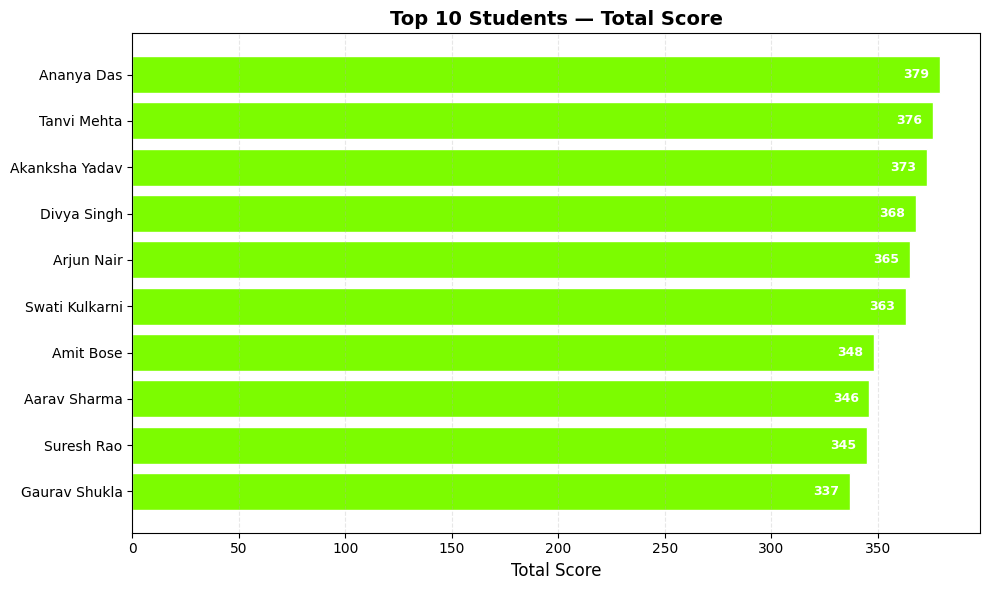

In [11]:
#Top 10 students
chart3_sql="""
SELECT
name,
(math_score+science_score+programming_score+attendance_percentage) AS total_marks
FROM students
ORDER BY total_marks DESC
LIMIT 10
"""
chart3_data=pd.read_sql_query(chart3_sql,conn)
fig,ax=plt.subplots(figsize=(10,6))
bar_colors=['#7CFC00']*10
bars=ax.barh(
    chart3_data['name'],
    chart3_data['total_marks'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1
)
ax.invert_yaxis()
for bar in bars:
    width=bar.get_width()
    ax.text(
        width-5,
        bar.get_y()+bar.get_height()/2,
        f"{int(width)}",
        ha='right',
        va='center',
        fontsize=9,
        fontweight='bold',
        color='white'
    )

ax.set_title(
    "Top 10 Students — Total Score",
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel("Total Score",fontsize=12)
ax.grid(axis='x',linestyle='--',alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
API_KEY='HARSHINI_ARUL_17'
print("Student Performance:")
print("API Key:",API_KEY)
response=requests.get('https://jsonplaceholder.typicode.com/users')
print("Request Status Code:",response.status_code)

Student Performance:
API Key: HARSHINI_ARUL_17
Request Status Code: 200


In [13]:
print("\nDataset Before Cleaning:")
print(df.head())
print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())
print("\nShape Before Cleaning:")
print(df.shape)
df=df.drop_duplicates()
df['name']=df['name'].fillna('Unknown')
df['gender']=df['gender'].fillna('Not Specified')
df['department']=df['department'].fillna('Unknown')
df['city']=df['city'].fillna('Unknown')
df['math_score']=df['math_score'].fillna(0)
df['science_score']=df['science_score'].fillna(0)
df['english_score']=df['english_score'].fillna(0)
df['programming_score']=df['programming_score'].fillna(0)
df['attendance_percentage']=df['attendance_percentage'].fillna(0)
print("\nDataset After Cleaning:")
print(df.head())
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())
print("\nShape After Cleaning:")
print(df.shape)
df.to_csv(
    'cleaned_student_performance.csv',
    index=False
)
print("\nCleaned CSV File Exported Successfully!")
print("\nETL Process Completed Successfully!")


Dataset Before Cleaning:
   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0        85.0             78           72.0                 91   
1        76.0             82           88.0                 79   
2        65.0             74           61.0                 55   
3        70.0             80           75.0                 48   
4        92.0             88           81.0                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad 

In [14]:
API_KEY='3929e5e1d84f27eadb79dc0459e00d9b'
BASE_URL='https://api.openweathermap.org/data/2.5/weather'
CITIES=['Dharapuram','Pollachi','Tiruppur','Chennai','Coimbatore','Karur','Dindigul','Erode']
print(f'API configured for {len(CITIES)} cities')
print(f'Cities:{CITIES}')
print('\nMy API key: 3929e5e1d84f27eadb79dc0459e00d9b')

API configured for 8 cities
Cities:['Dharapuram', 'Pollachi', 'Tiruppur', 'Chennai', 'Coimbatore', 'Karur', 'Dindigul', 'Erode']

My API key: 3929e5e1d84f27eadb79dc0459e00d9b


In [15]:
def fetch_weather(city, api_key):
    """
    Fetch current weather data for a given city.
    """
    params={
        'q': city,
        'appid': api_key,
        'units': 'metric'
    }
    try:
        response = requests.get(BASE_URL, params=params, timeout=10)
        if response.status_code==200:
            data = response.json()
            return {
                'city': city,
                'temperature': round(data['main']['temp'], 1),
                'feels_like': round(data['main']['feels_like'], 1),
                'humidity': data['main']['humidity'],
                'pressure': data['main']['pressure'],
                'wind_speed': data['wind']['speed'],
                'condition': data['weather'][0]['description'].title(),
                'visibility': data.get('visibility', 0) // 1000
            }
        else:
            print(f"ERROR {response.status_code} for {city}:{response.json().get('message')}")
            return None
    except requests.exceptions.ConnectionError:
        print(f'Connection Error for {city} - check internet connection')
        return None
print('Calling Weather API...')
weather_records=[]
for city in CITIES:
    print(f'Fetching: {city}...', end=' ')
    record=fetch_weather(city, API_KEY)
    if record:
        weather_records.append(record)
        print(f"{record['temperature']}°C,{record['condition']}")
    else:
        print('FAILED')
print(f'Successfully fetched: {len(weather_records)}/{len(CITIES)} cities')

Calling Weather API...
Fetching: Dharapuram... 29.7°C,Overcast Clouds
Fetching: Pollachi... 26.9°C,Overcast Clouds
Fetching: Tiruppur... 25.7°C,Overcast Clouds
Fetching: Chennai... 34.3°C,Overcast Clouds
Fetching: Coimbatore... 24.5°C,Overcast Clouds
Fetching: Karur... 31.1°C,Overcast Clouds
Fetching: Dindigul... 27.5°C,Overcast Clouds
Fetching: Erode... 30.2°C,Overcast Clouds
Successfully fetched: 8/8 cities


In [16]:
city=input("Enter City Name: ")
record=fetch_weather(city, API_KEY)
if record:
    print("\nWeather Details")
    print("City:", record['city'])
    print("Temperature:", record['temperature'], "°C")
    print("Feels Like:", record['feels_like'], "°C")
    print("Humidity:", record['humidity'], "%")
    print("Pressure:", record['pressure'], "hPa")
    print("Wind Speed:", record['wind_speed'], "m/s")
    print("Condition:", record['condition'])
    print("Visibility:", record['visibility'], "km")
else:
    print("Weather data not found.")

Enter City Name: Pollachi

Weather Details
City: Pollachi
Temperature: 26.9 °C
Feels Like: 28.9 °C
Humidity: 72 %
Pressure: 1013 hPa
Wind Speed: 7.2 m/s
Condition: Overcast Clouds
Visibility: 10 km


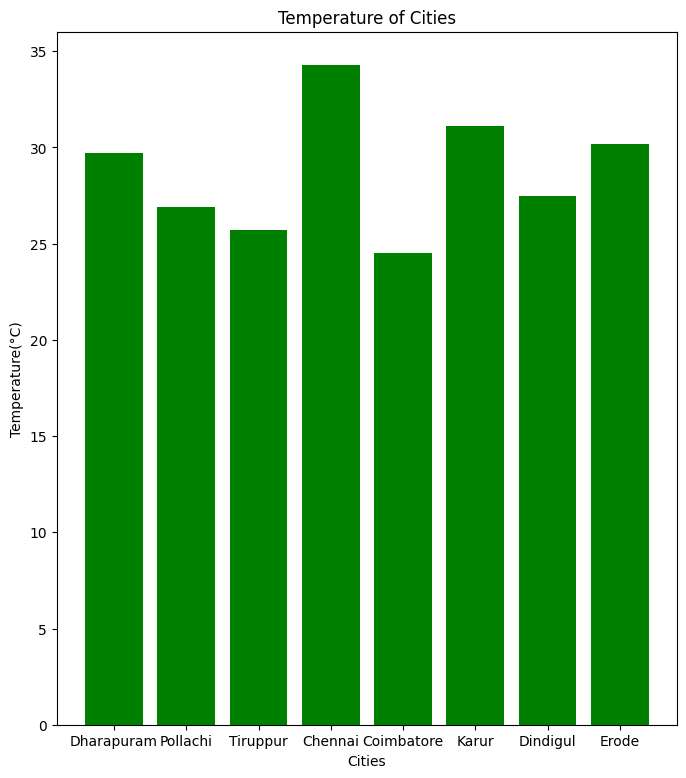

In [17]:
weather_df=pd.DataFrame(weather_records)
plt.figure(figsize=(8,9))
plt.bar(weather_df['city'],weather_df['temperature'],color='green')
plt.title('Temperature of Cities')
plt.xlabel('Cities')
plt.ylabel('Temperature(°C)')
plt.show()

In [18]:
#create spark session
spark=SparkSession.builder\
.appName('Day4_BigData_sales')\
.config('spark.sql.adaptive.enabled','true')\
.getOrCreate()

print(f'Spark Version: {spark.version}')
print(f'Spark Session: ACTIVE')
print(f'Application Name: {spark.sparkContext.appName}')

Spark Version: 4.0.2
Spark Session: ACTIVE
Application Name: Day4_BigData_sales


In [19]:
bronze_df = spark.read.csv("student_performance.csv", header=True, inferSchema=True)
print("BRONZE DATA")
bronze_df.show(5)

BRONZE DATA
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|student_id|        name|age|gender|      department|semester|math_score|science_score|english_score|programming_score|attendance_percentage|     city|admission_year|
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|      1001|Aarav Sharma| 19|  Male|Computer Science|       2|        85|           78|           72|               91|                   92|   Mumbai|          2023|
|      1002| Priya Patel| 20|Female|Computer Science|       2|        76|           82|           88|               79|                   87|Ahmedabad|          2023|
|      1003| Rohit Verma| 19|  Male|     Electronics|       2|        65|           74|           61|               55|                   78|    Delhi|  

In [20]:
silver_df = bronze_df.dropna()
silver_df = silver_df.withColumnRenamed("name", "student_name")
print("SILVER DATA")
silver_df.show(5)

SILVER DATA
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|student_id|student_name|age|gender|      department|semester|math_score|science_score|english_score|programming_score|attendance_percentage|     city|admission_year|
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|      1001|Aarav Sharma| 19|  Male|Computer Science|       2|        85|           78|           72|               91|                   92|   Mumbai|          2023|
|      1002| Priya Patel| 20|Female|Computer Science|       2|        76|           82|           88|               79|                   87|Ahmedabad|          2023|
|      1003| Rohit Verma| 19|  Male|     Electronics|       2|        65|           74|           61|               55|                   78|    Delhi|  

In [21]:
from pyspark.sql.functions import col
gold_df = silver_df.withColumn(
    "total_score",
    col("math_score") + col("science_score") +
    col("english_score") + col("programming_score")
)

print("GOLD DATA")
gold_df.show(5)

GOLD DATA
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+-----------+
|student_id|student_name|age|gender|      department|semester|math_score|science_score|english_score|programming_score|attendance_percentage|     city|admission_year|total_score|
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+-----------+
|      1001|Aarav Sharma| 19|  Male|Computer Science|       2|        85|           78|           72|               91|                   92|   Mumbai|          2023|        326|
|      1002| Priya Patel| 20|Female|Computer Science|       2|        76|           82|           88|               79|                   87|Ahmedabad|          2023|        325|
|      1003| Rohit Verma| 19|  Male|     Electronics|       2|        65|           74|        

In [24]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

df = pd.read_csv("student_performance.csv")

# Fill missing score values with 0 before calculating total_score
df['math_score'] = df['math_score'].fillna(0)
df['science_score'] = df['science_score'].fillna(0)
df['english_score'] = df['english_score'].fillna(0)
df['programming_score'] = df['programming_score'].fillna(0)
df['attendance_percentage'] = df['attendance_percentage'].fillna(0)

# Predict total score
df["total_score"] = (
    df["math_score"] +
    df["science_score"] +
    df["english_score"] +
    df["programming_score"]
)

X = df[["math_score", "science_score", "english_score",
        "programming_score", "attendance_percentage"]]

y = df["total_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = DecisionTreeRegressor(max_depth=5, random_state=42)

model.fit(X_train, y_train)

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("=== Decision Tree (max_depth=5) ===")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2  :", round(r2, 4))

=== Decision Tree (max_depth=5) ===
MAE : 25.95
RMSE: 36.66
R2  : 0.8086
